# **Gerador de Matriz de Confusão**

---

Versão 1.0.0

## **Importação das bibliotecas**

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## **Leitura do Arquivo CSV**

In [29]:
# Caminho do CSV

# ===== Testes em Campo =====
#name = "RF05EE080526"
#name = "RF10EE080526"
#name = "XGB05EE080526"
#name = "XGB10EE080526"

# ===== Testes em Campo Virtual =====
#name = "RF05EE080526VC"
#name = "RF10EE080526VC"
#name = "XGB05EE080526VC"
name = "XGB10EE080526VC"

arquivo = "../data/verification/PredicaoCampoVirtual/" + name + ".csv"  # <-- altera aqui
arquivo_saida = "../images/MatrizConfusaoCampo/matrizConfusao" + name + "Campo.png"

#nome = "XGB10"
#arquivo = "../data/verification/" + nome + ".csv"
#arquivo_saida = "../images/MatrizConfusaoCampo/matrizConfusao" + nome + ".png"

# Formatação dos dados no arquivo CSV
# data,hora,num,local,predição
# 24/03/2026,16:14:54,1,Lab. Informática 09,Sala dos técnicos
# 24/03/2026,16:15:04,2,Lab. Informática 09,Lab. de redes convergentes
# 24/03/2026,16:15:13,3,Lab. Informática 09,Lab. Informática 09

# Lê o CSV
df = pd.read_csv(arquivo)

## **Geração da Matriz**

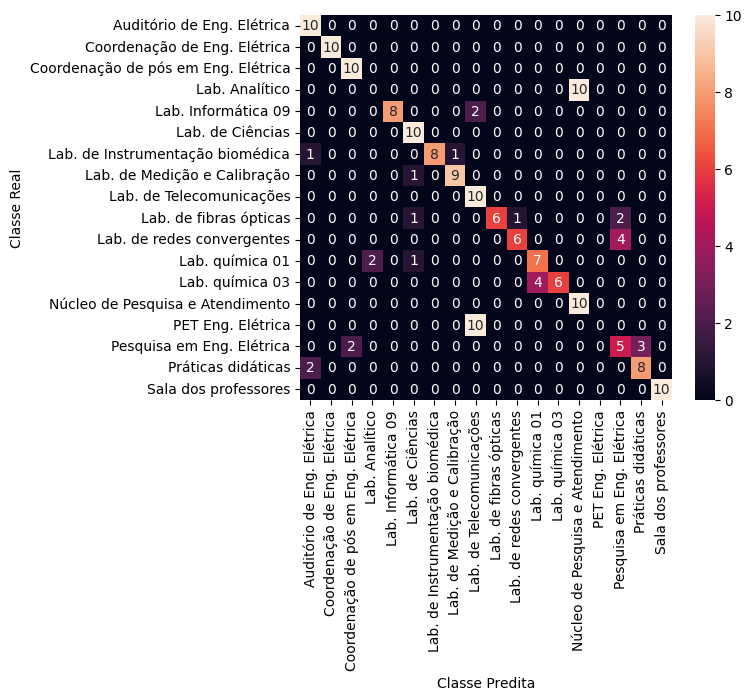

In [30]:
# Colunas reais e previstas
y_true = df["ambiente"]
y_pred = df["predição"]

# Garante todas as classes
labels = sorted(list(set(y_true) | set(y_pred)))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred, labels=labels)

# DataFrame da matriz (igual ao teu padrão)
cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

# Estrutura final
cm_df = cm_df.reset_index()
cm_df = cm_df.rename(columns={'index': 'Classe_Real'})

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels,
    #cmap="Greys",
    #linewidths=0.5,
    #linecolor='black'
)
# plt.title("Matriz de Confusão - XGBoost")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

# Salvar imagem
plt.savefig(arquivo_saida, dpi=1000, bbox_inches="tight")

plt.show()